In [ ]:
# Load 600M model
import torch
from E1 import dist
from E1.modeling import E1ForMaskedLM
from E1.msa_sampling import sample_context, ContextSpecification, sample_multiple_contexts
from E1.scorer import E1Scorer, EncoderScoreMethod
from E1.dynamic_cache import DynamicCache
from E1.batch_preparer import E1BatchPreparer


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import polars as pl
import numpy as np
from tqdm import tqdm
from copy import deepcopy
import polars as pl

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_name = "Profluent-Bio/E1-600m"
max_batch_tokens = 4096
scoring_method = EncoderScoreMethod.MASKED_MARGINAL
model = E1ForMaskedLM.from_pretrained(model_name, dtype=torch.float).to(dist.get_device()).eval()
batch_preparer = E1BatchPreparer()


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
fitness_repA_path = "../../data/Figure3_toxin_antitoxin/Library_fitness_vs_parE3_replicate_A.csv"
fitness_repB_path = "../../data/Figure3_toxin_antitoxin/Library_fitness_vs_parE3_replicate_B.csv"

wildtype_sequence = (
    "MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGRMAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF"
)
mut_pos_l = [58, 59, 60, 63]

fitness_repA = pd.read_csv(fitness_repA_path, index_col=None, header=None)
fitness_repB = pd.read_csv(fitness_repB_path, index_col=None, header=None)
query_seq_a = np.array(list(wildtype_sequence))
mutated_sequences = []
for (mut_a, rep_a), (mut_b, rep_b) in tqdm(zip(fitness_repA.values, fitness_repB.values), total=fitness_repA.shape[0]):
    mut_seq_a = deepcopy(query_seq_a)
    for i in range(4):
        mut_seq_a[mut_pos_l[i]] = mut_a[i]
    mutated_sequences.append("".join(mut_seq_a))
mutated_sequence_ids = np.arange(len(mutated_sequences))

100%|██████████| 9194/9194 [00:00<00:00, 52428.37it/s]


In [ ]:
msa_path = "../../data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m"

context_token_lengths = [7168, 14336, 21504]
max_query_similarities = [1.0, 0.95, 0.9, 0.7, 0.5]

context_specs = []
for max_num_tokens in context_token_lengths:
    for max_query_similarity in max_query_similarities:
        context_specs.append(
            ContextSpecification(
                # maximum number of sequences that can be sampled from the MSA (should be <= 1023)
                max_num_samples=1023,
                # maximum number of concatenated tokens in the context sequences
                max_token_length=max_num_tokens,
                # maximum similarity between the query and the context sequences
                max_query_similarity=max_query_similarity,
                # minimum similarity between the query and the context sequences
                min_query_similarity=0.0,
                # minimum similarity between the two sequences for them to be considered neighbors during MSA Sampling
                neighbor_similarity_lower_bound=0.8,
            )
        )

context_seqs, _ = sample_multiple_contexts(msa_path=msa_path, context_specifications=context_specs, seed=0)

context_seqs_dict = {f"context_{i}": seq for i, seq in enumerate(context_seqs)}

In [ ]:
scorer = E1Scorer(model, method=EncoderScoreMethod.MASKED_MARGINAL, max_batch_tokens=max_batch_tokens)
scores = scorer.score(
    parent_sequence=wildtype_sequence,  # parent sequence
    sequences=mutated_sequences,  # list of mutated sequences we want to score (substitutions only)
    sequence_ids=mutated_sequence_ids,  # list of sequence ids for each mutated sequence
    context_seqs=context_seqs_dict,  # dictionary of context sequences
    # we ensemble scores over multiple context sequences by taking mean; set to "none" to return
    # scores with respect to each context sequence individually
    context_reduction="mean",
)
print(scores[:10])
scores = pl.from_dicts(scores)
scores = pd.DataFrame(scores)
scores.columns = ['id', 'context_id', 'score']
scores.to_csv(
    "results/e1_600m_toxin_antitoxin.tsv",
    sep='\t',
)
scores.head()

Predicting batches:   0%|          | 0/60 [00:00<?, ?it/s]

Scoring sequences against parent: 100%|██████████| 9194/9194 [00:00<00:00, 80656.99it/s]

[{'id': np.int64(0), 'context_id': 'mean', 'score': -9.755792617797852}, {'id': np.int64(1), 'context_id': 'mean', 'score': -12.027472496032715}, {'id': np.int64(2), 'context_id': 'mean', 'score': -9.180793762207031}, {'id': np.int64(3), 'context_id': 'mean', 'score': -12.055988311767578}, {'id': np.int64(4), 'context_id': 'mean', 'score': -9.171418190002441}, {'id': np.int64(5), 'context_id': 'mean', 'score': -10.800064086914062}, {'id': np.int64(6), 'context_id': 'mean', 'score': -14.403189659118652}, {'id': np.int64(7), 'context_id': 'mean', 'score': -15.362043380737305}, {'id': np.int64(8), 'context_id': 'mean', 'score': -10.042707443237305}, {'id': np.int64(9), 'context_id': 'mean', 'score': -11.715038299560547}]


,id,context_id,score
0,0,mean,-9.755793
1,1,mean,-12.027472
2,2,mean,-9.180794
3,3,mean,-12.055988
4,4,mean,-9.171418


In [52]:
((((fitness_repA[1] + fitness_repB[1]) / 2) >= 0.15) & pd.Series(scores['score'] >= np.sort(np.array(scores['score']))[::-1][464])).sum() / 465

np.float64(0.5655913978494623)

## 1.2 Compute categorical jacobian

In [2]:
def jac_to_con(jac, center=True, diag="remove", apc=True,
               symm_before=True, symm_after=False):
    """Convert Jacobian to contact map"""
    X = jac.copy()
    Lx, Ax, Ly, Ay = X.shape

    if symm_before:
        X = X + X.transpose(2, 3, 0, 1)

    if center:
        for i in range(4):
            if X.shape[i] > 1:
                X -= X.mean(i, keepdims=True)

    contacts = np.sqrt(np.square(X).sum((1, 3)))

    if symm_after:
        contacts = contacts + contacts.T

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    if diag == "normalize":
        contacts_diag = np.diag(contacts)
        contacts = contacts / np.sqrt(contacts_diag[:, None] * contacts_diag[None, :])

    if apc:
        ap = contacts.sum(0, keepdims=True) * contacts.sum(1, keepdims=True) / contacts.sum()
        contacts = contacts - ap

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    return contacts


def clone_cache(cache: DynamicCache) -> DynamicCache:
    """Create a deep copy of a DynamicCache."""
    new_cache = DynamicCache()
    new_cache.key_cache = [k.clone() for k in cache.key_cache]
    new_cache.value_cache = [v.clone() for v in cache.value_cache]
    return new_cache


def get_categorical_jacobian_with_cache(
    batch,
    model,
    batch_preparer,
    query_idx_t,
    aa_indices_t,
    mutation_subset=None,
    show_progress=True
):
    """
    Compute categorical Jacobian using KV cache for context sequences.

    This optimized version:
    1. First forward pass: processes full input (context + query), caches context KVs
    2. Subsequent passes: only processes query tokens, reuses cached context KVs

    Speedup depends on context/query ratio. If context is 90% of tokens, expect ~10x speedup.
    """
    device = next(model.parameters()).device

    # Get context length from batch
    context_len = batch['context_len'][0]

    # Store original full batch tensors
    original_input_ids = batch['input_ids'].clone()
    original_within_seq_pos = batch['within_seq_position_ids'].clone()
    original_global_pos = batch['global_position_ids'].clone()
    original_sequence_ids = batch['sequence_ids'].clone()

    # Get WT tokens for the query (full indices)
    wt_tokens = original_input_ids[0, query_idx_t]

    # ========== First forward pass: build cache ==========
    batch['use_cache'] = True

    with torch.no_grad():
        with torch.autocast("cuda", torch.bfloat16):
            output = model(
                input_ids=batch["input_ids"],
                within_seq_position_ids=batch["within_seq_position_ids"],
                global_position_ids=batch["global_position_ids"],
                sequence_ids=batch["sequence_ids"],
                past_key_values=None,
                use_cache=True,
                output_attentions=False,
                output_hidden_states=False,
            )

    # Get WT logits (using full indices)
    fx = output['logits'][0, query_idx_t[2:-2]][:, aa_indices_t].float().cpu().numpy()

    # Extract and store the context-only cache
    full_cache = output.past_key_values

    # Crop cache to only context portion (remove query KVs)
    context_cache = DynamicCache()
    for layer_idx in range(len(full_cache.key_cache)):
        if full_cache.key_cache[layer_idx].numel():
            context_cache.key_cache.append(full_cache.key_cache[layer_idx][:, :context_len, ...].clone())
            context_cache.value_cache.append(full_cache.value_cache[layer_idx][:, :context_len, ...].clone())
        else:
            context_cache.key_cache.append(torch.tensor([]))
            context_cache.value_cache.append(torch.tensor([]))

    # Prepare query-only batch tensors (remove context)
    query_input_ids = original_input_ids[:, context_len:]
    query_within_seq_pos = original_within_seq_pos[:, context_len:]
    query_global_pos = original_global_pos[:, context_len:]
    query_sequence_ids = original_sequence_ids[:, context_len:]

    # Query indices are now relative to query-only tensor (0-indexed)
    query_len = query_input_ids.shape[1]
    query_indices_local = torch.arange(query_len, device=device)

    # Parse mutation subset
    if mutation_subset is None:
        mutation_indices = list(aa_indices_t.numpy())
    else:
        mutation_indices = mutation_subset

    # Initialize Jacobian matrix
    seq_length = query_idx_t.shape[0] - 4  # Exclude <bos>1 ... 2<eos>
    numAAs = aa_indices_t.shape[0]
    fx_h = np.zeros((seq_length, numAAs, seq_length, numAAs))

    # Progress bar
    if show_progress:
        iterator = tqdm(range(seq_length), desc='Computing categorical Jacobian (cached)')
    else:
        iterator = range(seq_length)

    # ========== Mutation forward passes: use cached context ==========
    for n in iterator:
        # Get WT AA at this position (in query-local coordinates, +2 for <bos>1)
        wt_aa = wt_tokens[n + 2]

        for idx, mutation_aa in enumerate(mutation_indices):
            if mutation_aa == wt_aa:
                # Skip computation for WT - use baseline
                fx_h[n, idx] = fx.copy()
            else:
                # Create mutated query input_ids
                mut_query_ids = query_input_ids.clone()
                # Position n+2 in query (accounting for <bos>1 prefix)
                mut_query_ids[0, n + 2] = mutation_aa

                # Clone cache for this forward pass (cache gets modified during forward)
                mutation_cache = clone_cache(context_cache)

                with torch.no_grad():
                    with torch.autocast("cuda", torch.bfloat16):
                        output = model(
                            input_ids=mut_query_ids,
                            within_seq_position_ids=query_within_seq_pos,
                            global_position_ids=query_global_pos,
                            sequence_ids=query_sequence_ids,
                            past_key_values=mutation_cache,
                            use_cache=True,
                            output_attentions=False,
                            output_hidden_states=False,
                        )

                # Extract logits for query residues (skip <bos>1 and 2<eos>)
                # In query-only output, indices are 2:-2 (same structure)
                fx_h[n, idx] = output['logits'][0, 2:-2][:, aa_indices_t].float().cpu().numpy()

    # Compute Jacobian: effect of mutation = WT_logits - mutant_logits
    result = fx - fx_h
    return result


def get_categorical_jacobian_no_cache(
    batch,
    model,
    query_idx_t,
    aa_indices_t,
    mutation_subset=None,
    show_progress=True
):
    """
    Original categorical Jacobian computation without KV cache.
    Kept for comparison/benchmarking.
    """
    input_ids = batch['input_ids']
    device = next(model.parameters()).device

    # Compute baseline logits for WT query sequence
    wt_tokens = input_ids[0, query_idx_t]

    with torch.no_grad():
        with torch.autocast("cuda", torch.bfloat16):
            output = model(
                input_ids=batch["input_ids"],
                within_seq_position_ids=batch["within_seq_position_ids"],
                global_position_ids=batch["global_position_ids"],
                sequence_ids=batch["sequence_ids"],
                past_key_values=None,
                use_cache=False,
                output_attentions=False,
                output_hidden_states=False,
            )
    fx = output['logits'][0, query_idx_t[2:-2]][:, aa_indices_t].float().cpu().numpy()

    # Parse mutation subset
    if mutation_subset is None:
        mutation_indices = list(aa_indices_t.numpy())
    else:
        mutation_indices = mutation_subset

    # Initialize Jacobian matrix
    seq_length = query_idx_t.shape[0] - 4
    numAAs = aa_indices_t.shape[0]
    fx_h = np.zeros((seq_length, numAAs, seq_length, numAAs))

    if show_progress:
        iterator = tqdm(range(seq_length), desc='Computing categorical Jacobian (no cache)')
    else:
        iterator = range(seq_length)

    for n in iterator:
        wt_aa = wt_tokens[n + 2]
        for idx, mutation_aa in enumerate(mutation_indices):
            if mutation_aa == wt_aa:
                fx_h[n, idx] = fx.copy()
            else:
                mut_tokens = input_ids.clone()
                mut_tokens[0, query_idx_t[n + 2]] = mutation_aa

                with torch.no_grad():
                    with torch.autocast("cuda", torch.bfloat16):
                        output = model(
                            input_ids=mut_tokens,
                            within_seq_position_ids=batch["within_seq_position_ids"],
                            global_position_ids=batch["global_position_ids"],
                            sequence_ids=batch["sequence_ids"],
                            past_key_values=None,
                            use_cache=False,
                            output_attentions=False,
                            output_hidden_states=False,
                        )
                fx_h[n, idx] = output['logits'][0, query_idx_t[2:-2]][:, aa_indices_t].float().cpu().numpy()

    result = fx - fx_h
    return result

In [ ]:
id_to_tok_d = {v: k for k, v in batch_preparer.tokenizer.get_vocab().items()}
aa_indices_t = torch.tensor([8, 25, 21, 11, 10, 12, 24, 14, 15, 16, 19, 18, 20, 13, 23, 26, 27, 30, 32, 29])
aa_l = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
assert len(aa_l) == aa_indices_t.shape[0]

max_token_length = 21504
max_depth = 1023
max_query_similarity = 0.9
min_query_similarity = 0.0
neighbor_similarity_lower_bound = 0.8
seed = 0

# Set to True to use KV cache optimization
use_cache = True

# Get query sequence
msa_path = "../../data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m"
with open(msa_path, "r") as oFile:
    query_seq = oFile.readlines()[1].strip()

# Parse MSA for context
context, _ = sample_context(
    msa_path=msa_path,
    max_num_samples=max_depth,
    max_token_length=max_token_length,
    max_query_similarity=max_query_similarity,
    min_query_similarity=min_query_similarity,
    neighbor_similarity_lower_bound=neighbor_similarity_lower_bound,
    seed=seed,
)
full_prompt = [context + ',' + query_seq]

batch = batch_preparer.get_batch_kwargs(full_prompt, device=device)

# Print context/query ratio for reference
context_len = batch['context_len'][0]
total_len = batch['input_ids'].shape[1]
query_len = total_len - context_len
print(f"  Context: {context_len} tokens, Query: {query_len} tokens, Ratio: {context_len/total_len:.1%}")

# Get token indices of query sequence
query_idx_t = torch.where(batch['sequence_ids'][0] == batch['sequence_ids'][0].max())[0]

# Compute Jacobian
if use_cache and context_len > 0:
    catjac_result = get_categorical_jacobian_with_cache(
        batch, model, batch_preparer, query_idx_t, aa_indices_t
    )
else:
    catjac_result = get_categorical_jacobian_no_cache(
        batch, model, query_idx_t, aa_indices_t
    )

catjac_contacts = jac_to_con(catjac_result)
np.savetxt("results/e1_600m_toxin_antitoxin_jacobian.txt", catjac_contacts)

  Context: 21941 tokens, Query: 200 tokens, Ratio: 99.1%


Computing categorical Jacobian (cached): 100%|██████████| 196/196 [06:44<00:00,  2.06s/it]


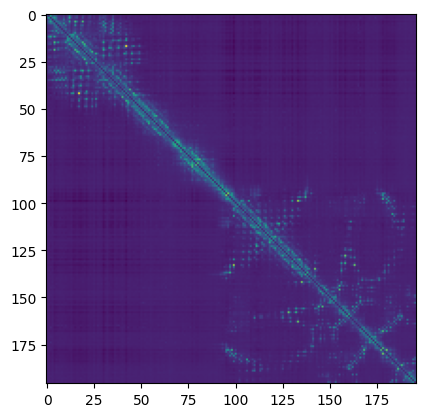

In [7]:
plt.imshow(catjac_contacts)